## Date and Time in Pandas 

In [2]:
import numpy as np 
import pandas as pd

### **Timestamp Object**

**Timestamp refers to a particular moments in time**

### **Creating Timestamp Objects**

In [3]:
# Creating the timestamp object
pd.Timestamp('2025/08/12')

Timestamp('2025-08-12 00:00:00')

In [4]:
type(pd.Timestamp('2025/08/12'))

pandas._libs.tslibs.timestamps.Timestamp

**Variations**

In [5]:
pd.Timestamp('2025-08-12')

Timestamp('2025-08-12 00:00:00')

In [6]:
pd.Timestamp('2025, 08, 12')

Timestamp('2025-08-12 00:00:00')

In [7]:
pd.Timestamp('2025')

Timestamp('2025-01-01 00:00:00')

In [8]:
# using text

pd.Timestamp('12th August 2025')

Timestamp('2025-08-12 00:00:00')

In [9]:
# Providing the time 
pd.Timestamp('12th August 2025 1:21AM')

Timestamp('2025-08-12 01:21:00')

**Using the datetime object**

In [10]:
import datetime as dt

x = dt.datetime(2025,8,12,1,21)

In [11]:
print(x.year)
print(x.month)
print(x.day)
print(x.hour)
print(x.minute)
print(x.second)

2025
8
12
1
21
0


#### **Why separate objects to handle data and time when python already has datetime functionality ?**

- Syntax wise datetime is very convenient

- But the performance takes a hit while working with huge data. List vs Numpy Array

- The weaknesses of Python's datetime format inspired the NumPy team to add a set of native time series data type to NumPy

- The datetime64 dtype encodes dates as 64-bit integers, and thus allows arrays of dates to be represented very compactly

In [12]:
date = np.array('2015-07-04', dtype=np.datetime64)
date

array('2015-07-04', dtype='datetime64[D]')

In [13]:
date + np.arange(12)

array(['2015-07-04', '2015-07-05', '2015-07-06', '2015-07-07',
       '2015-07-08', '2015-07-09', '2015-07-10', '2015-07-11',
       '2015-07-12', '2015-07-13', '2015-07-14', '2015-07-15'],
      dtype='datetime64[D]')

- Because of the uniform type in NumPy datetime64 arrays, this type of operation can be accomplished much more quickly than if we were working directly with Python's datetime objects, especially as arrays get large 

- Pandas Timestamp object combines the ease-of-use of python datetime with the efficient storage and vectorized interface of numpy.datetime64

- From a group of these Timestamp objects, Pandas can construct a DatetimeIndex that can be used to index data in a Series or DataFrame

### **DatetimeIndex Object**

**A collection of pandas timestamp**

In [14]:
# From String

pd.DatetimeIndex(['01/01/2023','01/01/2022','01/01/2021'])

DatetimeIndex(['2023-01-01', '2022-01-01', '2021-01-01'], dtype='datetime64[ns]', freq=None)

In [15]:
type(pd.DatetimeIndex(['01/01/2023','01/01/2022','01/01/2021']))

pandas.core.indexes.datetimes.DatetimeIndex

In [16]:
# Using python datetime object

pd.DatetimeIndex([dt.datetime(2023,1,1),dt.datetime(2022,1,1),dt.datetime(2021,1,1)])

DatetimeIndex(['2023-01-01', '2022-01-01', '2021-01-01'], dtype='datetime64[ns]', freq=None)

In [17]:
# Using pd.Timestamp

dt_index = pd.DatetimeIndex([pd.Timestamp(2023,1,1),pd.Timestamp(2022,1,1),pd.Timestamp(2021,1,1)])

In [18]:
# Using datetimeIndex as series index

pd.Series([1,2,3],index=dt_index)

2023-01-01    1
2022-01-01    2
2021-01-01    3
dtype: int64

### **Date_range function**

In [19]:
# Generate the daily dates in given range
pd.date_range(start='2004/08/12',end='2025/08/12')

DatetimeIndex(['2004-08-12', '2004-08-13', '2004-08-14', '2004-08-15',
               '2004-08-16', '2004-08-17', '2004-08-18', '2004-08-19',
               '2004-08-20', '2004-08-21',
               ...
               '2025-08-03', '2025-08-04', '2025-08-05', '2025-08-06',
               '2025-08-07', '2025-08-08', '2025-08-09', '2025-08-10',
               '2025-08-11', '2025-08-12'],
              dtype='datetime64[ns]', length=7671, freq='D')

In [20]:
# Alternate days in given range

pd.date_range(start='2004/08/12',end='2025/08/12',freq='2D')

DatetimeIndex(['2004-08-12', '2004-08-14', '2004-08-16', '2004-08-18',
               '2004-08-20', '2004-08-22', '2004-08-24', '2004-08-26',
               '2004-08-28', '2004-08-30',
               ...
               '2025-07-25', '2025-07-27', '2025-07-29', '2025-07-31',
               '2025-08-02', '2025-08-04', '2025-08-06', '2025-08-08',
               '2025-08-10', '2025-08-12'],
              dtype='datetime64[ns]', length=3836, freq='2D')

In [21]:
# For business days

pd.date_range(start='2004/08/12',end='2025/08/12',freq='B')

DatetimeIndex(['2004-08-12', '2004-08-13', '2004-08-16', '2004-08-17',
               '2004-08-18', '2004-08-19', '2004-08-20', '2004-08-23',
               '2004-08-24', '2004-08-25',
               ...
               '2025-07-30', '2025-07-31', '2025-08-01', '2025-08-04',
               '2025-08-05', '2025-08-06', '2025-08-07', '2025-08-08',
               '2025-08-11', '2025-08-12'],
              dtype='datetime64[ns]', length=5479, freq='B')

In [22]:
# one week per day

pd.date_range(start='2004/08/12',end='2025/08/12',freq='W')

DatetimeIndex(['2004-08-15', '2004-08-22', '2004-08-29', '2004-09-05',
               '2004-09-12', '2004-09-19', '2004-09-26', '2004-10-03',
               '2004-10-10', '2004-10-17',
               ...
               '2025-06-08', '2025-06-15', '2025-06-22', '2025-06-29',
               '2025-07-06', '2025-07-13', '2025-07-20', '2025-07-27',
               '2025-08-03', '2025-08-10'],
              dtype='datetime64[ns]', length=1096, freq='W-SUN')

In [23]:
# Hourly Data 
pd.date_range(start='2004/08/12',end='2025/08/12',freq='h')

DatetimeIndex(['2004-08-12 00:00:00', '2004-08-12 01:00:00',
               '2004-08-12 02:00:00', '2004-08-12 03:00:00',
               '2004-08-12 04:00:00', '2004-08-12 05:00:00',
               '2004-08-12 06:00:00', '2004-08-12 07:00:00',
               '2004-08-12 08:00:00', '2004-08-12 09:00:00',
               ...
               '2025-08-11 15:00:00', '2025-08-11 16:00:00',
               '2025-08-11 17:00:00', '2025-08-11 18:00:00',
               '2025-08-11 19:00:00', '2025-08-11 20:00:00',
               '2025-08-11 21:00:00', '2025-08-11 22:00:00',
               '2025-08-11 23:00:00', '2025-08-12 00:00:00'],
              dtype='datetime64[ns]', length=184081, freq='h')

In [24]:
pd.date_range(start='2004/08/12',end='2025/08/12',freq='6h')

DatetimeIndex(['2004-08-12 00:00:00', '2004-08-12 06:00:00',
               '2004-08-12 12:00:00', '2004-08-12 18:00:00',
               '2004-08-13 00:00:00', '2004-08-13 06:00:00',
               '2004-08-13 12:00:00', '2004-08-13 18:00:00',
               '2004-08-14 00:00:00', '2004-08-14 06:00:00',
               ...
               '2025-08-09 18:00:00', '2025-08-10 00:00:00',
               '2025-08-10 06:00:00', '2025-08-10 12:00:00',
               '2025-08-10 18:00:00', '2025-08-11 00:00:00',
               '2025-08-11 06:00:00', '2025-08-11 12:00:00',
               '2025-08-11 18:00:00', '2025-08-12 00:00:00'],
              dtype='datetime64[ns]', length=30681, freq='6h')

In [25]:
# For month end 

pd.date_range(start='2004/08/12',end='2025/08/12',freq='ME')

DatetimeIndex(['2004-08-31', '2004-09-30', '2004-10-31', '2004-11-30',
               '2004-12-31', '2005-01-31', '2005-02-28', '2005-03-31',
               '2005-04-30', '2005-05-31',
               ...
               '2024-10-31', '2024-11-30', '2024-12-31', '2025-01-31',
               '2025-02-28', '2025-03-31', '2025-04-30', '2025-05-31',
               '2025-06-30', '2025-07-31'],
              dtype='datetime64[ns]', length=252, freq='ME')

In [26]:
# For month start 
pd.date_range(start='2004/08/12',end='2025/08/12',freq='MS')

DatetimeIndex(['2004-09-01', '2004-10-01', '2004-11-01', '2004-12-01',
               '2005-01-01', '2005-02-01', '2005-03-01', '2005-04-01',
               '2005-05-01', '2005-06-01',
               ...
               '2024-11-01', '2024-12-01', '2025-01-01', '2025-02-01',
               '2025-03-01', '2025-04-01', '2025-05-01', '2025-06-01',
               '2025-07-01', '2025-08-01'],
              dtype='datetime64[ns]', length=252, freq='MS')

In [27]:
# For year end 

pd.date_range(start='2004/08/12',end='2025/08/12',freq='YE')

DatetimeIndex(['2004-12-31', '2005-12-31', '2006-12-31', '2007-12-31',
               '2008-12-31', '2009-12-31', '2010-12-31', '2011-12-31',
               '2012-12-31', '2013-12-31', '2014-12-31', '2015-12-31',
               '2016-12-31', '2017-12-31', '2018-12-31', '2019-12-31',
               '2020-12-31', '2021-12-31', '2022-12-31', '2023-12-31',
               '2024-12-31'],
              dtype='datetime64[ns]', freq='YE-DEC')

In [28]:
# Using periods (number of results)

pd.date_range(start='2004/08/12',periods=20,freq='h')

DatetimeIndex(['2004-08-12 00:00:00', '2004-08-12 01:00:00',
               '2004-08-12 02:00:00', '2004-08-12 03:00:00',
               '2004-08-12 04:00:00', '2004-08-12 05:00:00',
               '2004-08-12 06:00:00', '2004-08-12 07:00:00',
               '2004-08-12 08:00:00', '2004-08-12 09:00:00',
               '2004-08-12 10:00:00', '2004-08-12 11:00:00',
               '2004-08-12 12:00:00', '2004-08-12 13:00:00',
               '2004-08-12 14:00:00', '2004-08-12 15:00:00',
               '2004-08-12 16:00:00', '2004-08-12 17:00:00',
               '2004-08-12 18:00:00', '2004-08-12 19:00:00'],
              dtype='datetime64[ns]', freq='h')

### **to_datetime() function**

**converts an existing objects to pandas timestamp / datetimeindex object**

In [29]:
s = pd.Series(['2023/01/01','2024/01/01','2025/01/01'])
s

0    2023/01/01
1    2024/01/01
2    2025/01/01
dtype: object

In [30]:
pd.to_datetime(s).dt.day_name()

0       Sunday
1       Monday
2    Wednesday
dtype: object

In [31]:
pd.to_datetime(s).dt.month_name()

0    January
1    January
2    January
dtype: object

In [32]:
print(pd.to_datetime(s).dt.day)
print(pd.to_datetime(s).dt.month)
print(pd.to_datetime(s).dt.year)

0    1
1    1
2    1
dtype: int32
0    1
1    1
2    1
dtype: int32
0    2023
1    2024
2    2025
dtype: int32


In [33]:
# When error occur

s = pd.Series(['2023/01/01','2024/130/01','2025/01/01'])
# pd.to_datetime(s)  # This will give error 

In [34]:
pd.to_datetime(s,errors='coerce')  # all things we can perform on this

0   2023-01-01
1          NaT
2   2025-01-01
dtype: datetime64[ns]

In [35]:
df = pd.read_csv('Datasets/expense_data.csv')
df.sample(5)

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
180,12/21/2021 11:43,CUB - online payment,Food,NaN,Bun,18.0,Expense,NaN,18.0,INR,18.0
104,1/15/2022 21:16,CUB - online payment,Other,NaN,From dad,1500.0,Income,NaN,1500.0,INR,1500.0
134,1/5/2022 14:37,CUB - online payment,Other,NaN,To abijith and to vicky lend money returned,500.0,Expense,NaN,500.0,INR,500.0
183,12/20/2021 16:55,CUB - online payment,Food,NaN,Snacks,20.0,Expense,NaN,20.0,INR,20.0
258,11/26/2021 20:57,CUB - online payment,Food,NaN,Snack,102.0,Expense,NaN,102.0,INR,102.0


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            277 non-null    object 
 1   Account         277 non-null    object 
 2   Category        277 non-null    object 
 3   Subcategory     0 non-null      float64
 4   Note            273 non-null    object 
 5   INR             277 non-null    float64
 6   Income/Expense  277 non-null    object 
 7   Note.1          0 non-null      float64
 8   Amount          277 non-null    float64
 9   Currency        277 non-null    object 
 10  Account.1       277 non-null    float64
dtypes: float64(5), object(6)
memory usage: 23.9+ KB


In [37]:
# Convert Date column dtype to datetime

df['Date'] = pd.to_datetime(df['Date'])

In [38]:
# dt accessor  (all things that we applied , can be applied here)

# Example 
# df['Date'].dt.is_leap_year
# df['Date'].dt.is_year_start

#### **Ploting Graph**

In [39]:
import matplotlib.pyplot as plt

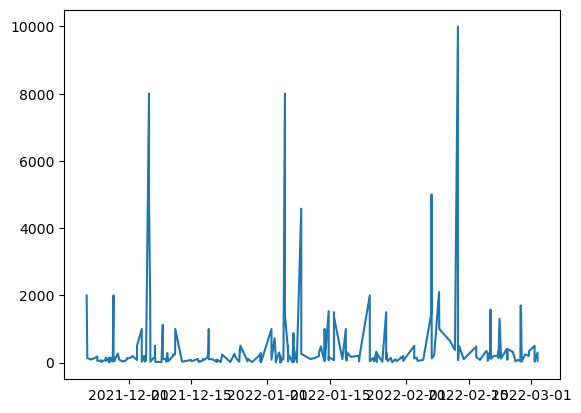

In [40]:
plt.plot(df['Date'],df['INR'])

In [41]:
df['Day_name'] = df['Date'].dt.day_name()

In [42]:
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,Day_name
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,Wednesday
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,Wednesday
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,Tuesday
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,Tuesday
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,Tuesday


<Axes: xlabel='Day_name'>

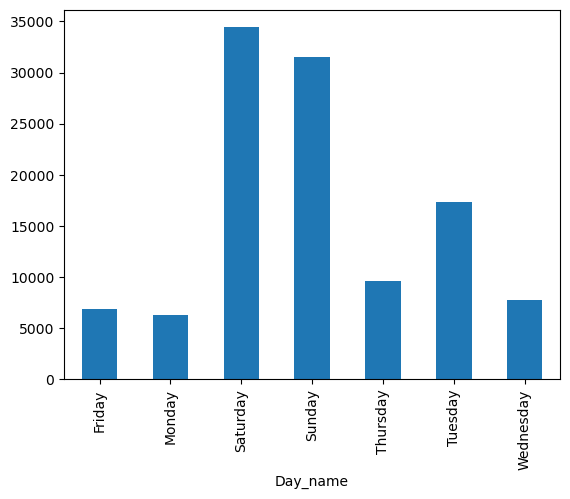

In [43]:
df.groupby('Day_name')['INR'].sum().plot(kind='bar')

In [44]:
df['Month_name'] = df['Date'].dt.month_name()

In [45]:
df['Day_name'] = df['Date'].dt.day_name()

<Axes: xlabel='Month_name'>

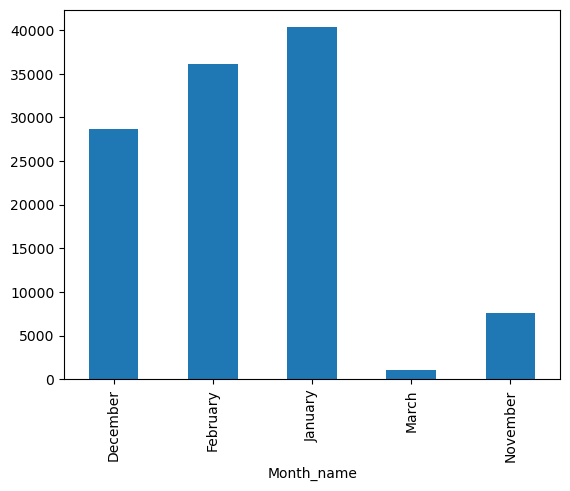

In [46]:
df.groupby('Month_name')['INR'].sum().plot(kind='bar')

In [47]:
df[df['Date'].dt.is_month_end]

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,Day_name,Month_name
7,2022-02-28 11:56:00,CUB - online payment,Food,NaN,Pizza,339.15,Expense,NaN,339.15,INR,339.15,Monday,February
8,2022-02-28 11:45:00,CUB - online payment,Other,NaN,From kumara,200.00,Income,NaN,200.00,INR,200.00,Monday,February
61,2022-01-31 08:44:00,CUB - online payment,Transportation,NaN,Vnr to apk,50.00,Expense,NaN,50.00,INR,50.00,Monday,January
62,2022-01-31 08:27:00,CUB - online payment,Other,NaN,To vicky,200.00,Expense,NaN,200.00,INR,200.00,Monday,January
63,2022-01-31 08:26:00,CUB - online payment,Transportation,NaN,To ksr station,153.00,Expense,NaN,153.00,INR,153.00,Monday,January
242,2021-11-30 14:24:00,CUB - online payment,Gift,NaN,Bharath birthday,115.00,Expense,NaN,115.00,INR,115.00,Tuesday,November
243,2021-11-30 14:17:00,CUB - online payment,Food,NaN,Lunch with company,128.00,Expense,NaN,128.00,INR,128.00,Tuesday,November
244,2021-11-30 10:11:00,CUB - online payment,Food,NaN,Breakfast,70.00,Expense,NaN,70.00,INR,70.00,Tuesday,November


### **Time delta object**

**In pandas, a Timedelta object represents the difference or duration between two dates, times, or datetime values**

In [ ]:
# Creating the timedelta using timestamp

t1 = pd.Timestamp('6 jan 2023 9:15')
t2 = pd.Timestamp('26 jan 2023 6:10')

t2 - t1

Timedelta('19 days 20:55:00')

In [ ]:
# Creating the timedelta object

pd.Timedelta(days=20,hours=15,minutes=59)

Timedelta('20 days 15:59:00')

In [ ]:
# Arithmetic Operation

pd.Timestamp('12 Aug 2025') + pd.Timedelta(days=20,hours=15,minutes=59)

Timestamp('2025-09-01 15:59:00')

In [57]:
# on Datetime Index

pd.date_range(start='12 Aug 2004',end='12 Aug 2005') + pd.Timedelta(days=20,hours=15,minutes=59)

DatetimeIndex(['2004-09-01 15:59:00', '2004-09-02 15:59:00',
               '2004-09-03 15:59:00', '2004-09-04 15:59:00',
               '2004-09-05 15:59:00', '2004-09-06 15:59:00',
               '2004-09-07 15:59:00', '2004-09-08 15:59:00',
               '2004-09-09 15:59:00', '2004-09-10 15:59:00',
               ...
               '2005-08-23 15:59:00', '2005-08-24 15:59:00',
               '2005-08-25 15:59:00', '2005-08-26 15:59:00',
               '2005-08-27 15:59:00', '2005-08-28 15:59:00',
               '2005-08-29 15:59:00', '2005-08-30 15:59:00',
               '2005-08-31 15:59:00', '2005-09-01 15:59:00'],
              dtype='datetime64[ns]', length=366, freq='D')

In [60]:
# Real dataset example 
# Loading the dataset 

order = pd.read_csv('Datasets/deliveries.csv')
order.sample(5)

,order_date,delivery_date
509,7/5/23,7/17/23
944,11/20/22,11/22/22
440,7/1/12,7/6/12
414,4/11/17,4/14/17
420,6/8/12,6/12/12


In [61]:
order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   order_date     1000 non-null   object
 1   delivery_date  1000 non-null   object
dtypes: object(2)
memory usage: 15.8+ KB


In [74]:
order['order_date'] = pd.to_datetime(order['order_date'], format='%m/%d/%y')
order['delivery_date'] = pd.to_datetime(order['delivery_date'], format='%m/%d/%y')

In [75]:
order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_date     1000 non-null   datetime64[ns]
 1   delivery_date  1000 non-null   datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 15.8 KB


In [78]:
# Lets take out the delivery period

order['delivery_period'] = order['delivery_date'] - order['order_date']

In [79]:
order.sample(5)

,order_date,delivery_date,delivery_period
619,2015-10-31,2015-11-02,2 days
573,2019-11-27,2019-12-09,12 days
357,2016-04-17,2016-04-21,4 days
423,2015-11-23,2015-11-25,2 days
467,2015-03-08,2015-03-11,3 days


In [80]:
# To check the average delivery time

order['delivery_period'].mean()

Timedelta('7 days 16:16:19.200000')